# DISEÑO DEL PROYECTO

Este caso simula que somos una empresa inmobiliaria que hace inversiones en grandes ciudades comprando inmuebles para posteriormente alquilarlos como apartamentos turísticos.

La dirección ha tomado la decisión de invertir en Madrid, y nos ha encargado analizar los datos que el líder del sector AirBnb hace públicos para intentar encontrar los tipos de inmuebles que tienen mayor potencial comercial para alquier turístico.

Como entregable principal esperan la tipología (o tipologías) de inmuebles que el equipo de valoraciones debe buscar entre las oportunidades existentes en la ciudad y los principales barrios o zonas geográficas en las que focalizarse.

Para cumplir con el objetivo aplicaremos la metodología de Discovery y las técnicas de Business Analytics.

Aunque este caso esté centrado en el **alquiler turístico**, el mismo enfoque se puede usar en situaciones con alto componente de **ubicación**

## OBJETIVO

Localizar el perfil (o perfiles) de inmuebles que maximizan el potencial comercial en el mercado del alquiler turístico y las principales zonas donde buscarlos.

## PALANCAS

Tras hablar con el equipo de valoraciones nos dicen que las palancas que tienen más impacto en la rentabilidad de este tipo de inversiones son:

* **Precio alquiler**: cuanto más se pueda cobrar por noche mayor es la rentabilidad
* **Ocupación**: en general cuantos más días al año se pueda alquilar un inmueble mayor es su rentabilidad
* **Precio inmueble**: cuanto más barato se pueda adquirir la propiedad mayor es la rentabilidad

## KPIs

* Mediremos la ocupación como el número de días anuales que el inmueble se pueda alquilar. Núm de dias al año alquilado / 365 días = ratio de ocupación.
* Mediremos el precio del alquiler como el precio por noche en euros según Airbnb.
* Mediremos el precio de un inmueble como la multiplicación entre el número de metros cuadrados y el precio medio del m2 en su zona, y aplicaremos un 25% de descuento sobre el precio oficial por la fuerza de negociciación de nuestro equipo de compras.

## ENTIDADES Y DATOS

Las entidades relevantes para nuestro objetivo y de las que podemos disponer de datos son:

* Inmuebles
* Propietarios
* Distritos

## PREGUNTAS SEMILLA

Sobre el precio del alquiler:

* ¿Cuál es el precio medio? ¿y el rango de precios?¿Y por distritos?¿Y por barrios?
* ¿Cuál es el ranking de distritos y barrios por precio medio de alquiler?
* ¿Qué factores (a parte de la localización) determinan el precio del alquiler?
* ¿Cuál es la relación entre el tamaño del inmueble y el precio por el que se puede alquilar?
* ¿Cómo influye la competencia (número de inmuebles disponibles por barrio) sobre el precio del alquiler?
* ¿Cómo varían los precios por tipo de alquiler (todo el piso, habitación privada, habitación compartida)?

Sobre la ocupación:

* ¿Cual es la ocupación media? ¿Y por distritos?¿Y por barrios?
* ¿Cómo de probable es cada nivel de ocupación en cada distrito?
* ¿Cual es el ranking de distritos y barrios por ocupación?
* ¿Qué factores (a parte de la localización) determinan la ocupación?
* ¿Cual es la relación entre el tamaño del inmueble y su grado de ocupación?
* ¿Cómo influye la competencia (num inmuebles disponibles por barrio) sobre la ocupación?

Sobre el precio de compra:

* ¿Cual es el ranking de precio por m2 por distrito?
* ¿Cual es el ranking de precio del inmueble (m2 * tamaño medio) por distrito?
* ¿Cual es la relación entre el precio del inmueble y el precio del alquiler por distrito?
* ¿Cual es la relación entre el precio del inmueble y la ocupación por distrito?

# Importación de Datos

Tomamos los datos de Madrid (Junio de 2026) de la web:

https://insideairbnb.com/es/get-the-data/

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import requests
import os
from pathlib import Path
print('librerías importadas!')

librerías importadas!


In [3]:
# URLs de los archivos
url_listings = "https://data.insideairbnb.com/spain/comunidad-de-madrid/madrid/2026-06-20/visualisations/listings.csv"
url_listings_det = "https://data.insideairbnb.com/spain/comunidad-de-madrid/madrid/2026-06-20/data/listings.csv.gz"

# Descargar listings (CSV normal)
listings = pd.read_csv(url_listings)

# Descargar listings_det (CSV comprimido en gzip)
listings_det = pd.read_csv(url_listings_det, compression="gzip")

# Comprobar carga
display(listings.head(2))
display(listings_det.head(2))

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,1008521039996399925,Alojamiento tranquilo,509530871.0,1.470291e+18,Sandra,Carabanchel,Opañel,40.387990,-3.72470,Private room,42.0,1.0,0,NaN,NaN,1.0,268,0,NaN
1,887679074200493161,Hermoso para disfrutar Madrid,425181129.0,1.469928e+18,Felix,Puente de Vallecas,Palomeras Sureste,40.385482,-3.64084,Entire home/apt,210.0,1.0,1,2023-05-14,0.03,1.0,364,0,NaN


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1008521039996399925,https://www.airbnb.com/rooms/1008521039996399925,20260620164952,2026-06-20,city scrape,Alojamiento tranquilo,You'll be in a family and quiet atmosphere.,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,509530871,...,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN
1,887679074200493161,https://www.airbnb.com/rooms/887679074200493161,20260620164952,2026-06-20,city scrape,Hermoso para disfrutar Madrid,Enjoy the simplicity of this quiet and central...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,425181129,...,5.0,5.0,5.0,NaN,NaN,1,1,0,0,0.03


## Análisis y transformaciones para Calidad de Datos

In [4]:
# Eliminamos en el primer df las columnas que no necesitamos:
a_eliminar = ['host_id', 'host_name', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count', 'number_of_reviews_ltm', 'license']
listings = listings.drop(columns = a_eliminar)

In [5]:
# Eliminar filas con nulos:
listings = listings.dropna()

In [6]:
# En la columna room_type tenemos que uno de los tipos es habitación de hotel.
# Por lo tanto, eliminamos esas filas:
listings = listings[listings['room_type'] != 'Hotel room']

In [7]:
# Analizamos las columnas numéricas de interes del df listings:
listings.iloc[:, 7:].describe().T

,count,mean,std,min,25%,50%,75%,max
price,19010.0,180.261704,557.937964,3.0,83.0,125.0,184.0,36883.0
minimum_nights,19010.0,6.891320,14.372763,1.0,1.0,2.0,4.0,365.0
availability_365,19010.0,222.221042,110.951101,0.0,124.0,246.0,324.0,365.0


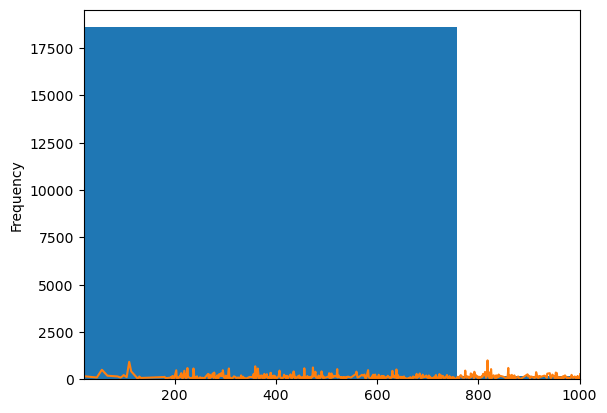

In [8]:
listings[(listings['price'] >= 20)]['price'].plot(kind='hist', bins=50, xlim=(20, 1000));
listings[(listings['price'] <= 1000)]['price'].plot();

# Viendo los histogramas, podemos hacer un corte en 20 min y 1000 max.
listings = listings[(listings['price'] >= 20) & (listings['price'] <= 1000)]

El df listings_det incluye 76 columnas, nos quedamos sólamente con las necesarias para nuestro informe.

In [9]:
a_incluir = ['id', 'description', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'review_scores_location', 'estimated_occupancy_l365d']

listings_det = listings_det[a_incluir]

Como necesitaremos estimar el valor de los pisos, necesitamos el número de habitaciones que tiene cada casa para poder realizar nuestro cálculo, por lo tanto eliminaremos las que tienen un número fuera de lo normal o con muy pocos casos.

En la variable estimated_occupancy_l365d, eliminamos los registros que son igual a cero.

Mediante listings_det.duplicated().sum() comprobamos que no tenemos registros dupicados.

In [10]:
# Eliminamos pisos con estimated_occupancy_l365d = 0:
listings_det = listings_det[listings_det['estimated_occupancy_l365d'] != 0]
# Eliminamos pisos con accomodates superiores a 8:
listings_det = listings_det[listings_det['accommodates']<=8]
# Eliminamos pisos con bathrooms superiores a 5:
listings_det = listings_det[listings_det['bathrooms']<=5]
# Eliminamos pisos con bedrooms superiores a 5:
listings_det = listings_det[listings_det['bedrooms']<=5]
# Eliminamos pisos con beds superiores a 6:
listings_det = listings_det[listings_det['beds']<=6]

## Incorporación de datos externos:

Vamos a intentar estimar por las habitaciones que tenemos el tamaño del piso, y mediante datos externos vemos el valor del metro cuadrado por distrito. Lo haré mediante la web https://www.idealista.com/sala-de-prensa/informes-precio-vivienda/venta/madrid-comunidad/madrid-provincia/madrid/
Mediante la extensión "instant data scraper" descargamos los datos en un csv.

In [11]:
# Cargar y corregir el df
idealista = pd.read_csv('../datos/brutos/idealista.csv')
idealista.columns = ['precio', 'distrito']
idealista = idealista.iloc[1:]
idealista['precio'] = idealista['precio'].str.replace(' €/m2', '').str.replace('.', '').astype(int)
# idealista['precio'] = idealista['precio'].str.split(expand=True)[0].str.replace('.', '').astype(int)

# Adapto los nombres diferentes de idealista para que estén como en listings:
mapeo_distritos = {'San Blas': 'San Blas - Canillejas',
    'Fuencarral': 'Fuencarral - El Pardo',
    'Moncloa': 'Moncloa - Aravaca'}
idealista['distrito'] = idealista['distrito'].replace(mapeo_distritos)
idealista.head(2)

,precio,distrito
1,6389,Arganzuela
2,5111,Barajas


## Creación de una base de datos para todas nuestras tablas.

In [12]:
import sqlite3
# Creamos la base de datos con sqlite:
con: Connection = sqlite3.connect('../datos/intermedios/mercado_inmobiliario.db')
# con = sqlite3.connect('mercado_inmobiliario.db')
# Guardar las 3 tablas:
listings.to_sql('listings', con = con, if_exists = 'replace', index=False)
listings_det.to_sql('listings_det', con = con, if_exists = 'replace', index=False)
idealista.to_sql('idealista', con = con, if_exists = 'replace', index=False)

con.close()

# Fase de Creación de variables

In [13]:
# Cargamos los datos para trabajar en ellos:
con = sqlite3.connect('../datos/intermedios/mercado_inmobiliario.db')
listings = pd.read_sql('SELECT * FROM listings', con)
listings_det = pd.read_sql('SELECT * FROM listings_det', con)
precio = pd.read_sql('SELECT * FROM idealista', con)
con.close()

## Integración de las tablas en un Tablón Analítico

In [14]:
# Merge inner join entre listings y listings_det
df_listings = pd.merge(listings, listings_det, on='id', how='inner')
# Merge left join entre df_listings y precio
df = pd.merge(df_listings, precio, left_on='neighbourhood_group', right_on='distrito', how='left')
# Eliminar id y neighbourhood_group de df:
df = df.drop(columns=['id', 'neighbourhood_group'])
# Renombrar price a precio_noche, y precio a precio_m2:
df = df.rename(columns={'price':'precio_noche', 'precio':'precio_m2'})
df.head(2)

,name,host_profile_id,neighbourhood,latitude,longitude,room_type,precio_noche,minimum_nights,availability_365,description,accommodates,bathrooms,bedrooms,beds,review_scores_location,estimated_occupancy_l365d,precio_m2,distrito
0,Piso de lujo en el centro,1.463373e+18,Palacio,40.412543,-3.713438,Entire home/apt,503.0,1.0,358,"This special place is close to everything, mak...",6,2.0,3.0,3.0,4.92,78,7636,Centro
1,Cute & Renewed apartment in Moncloa/Tetuán,1.462860e+18,Berruguete,40.455810,-3.703500,Entire home/apt,166.0,1.0,254,"Great, newly renovated apartment. Very bright ...",2,1.0,1.0,1.0,4.78,186,6147,Tetuán


## Integración de nuevas variables:

Puesto que no siempre van a estar ocupadas todas las habitaciones, partimos del supuesto de que de media están ocupadas la mitad de las habitaciones, por lo tanto una tasa de uso del 0,5.

In [15]:
tasa_uso = 0.5
condiciones = [
    df['room_type'] == 'Entire home/apt',
    df['room_type'] == 'Private room',
    df['room_type'] == 'Shared room']
opciones = [
    df['precio_noche'],
    df['precio_noche'] * df['bedrooms'] * tasa_uso,
    df['precio_noche'] * df['accommodates'] * tasa_uso]
df['precio_noche_total'] = np.select(condiciones, opciones, default=np.nan)

In [16]:
# Crear una variable ingreso_anual, que sea multiplicar precio_noche_total * estimated_occupancy_l365d:
df['ingreso_anual'] = df['precio_noche_total'] * df['estimated_occupancy_l365d']
df.head(2)

,name,host_profile_id,neighbourhood,latitude,longitude,room_type,precio_noche,minimum_nights,availability_365,description,accommodates,bathrooms,bedrooms,beds,review_scores_location,estimated_occupancy_l365d,precio_m2,distrito,precio_noche_total,ingreso_anual
0,Piso de lujo en el centro,1.463373e+18,Palacio,40.412543,-3.713438,Entire home/apt,503.0,1.0,358,"This special place is close to everything, mak...",6,2.0,3.0,3.0,4.92,78,7636,Centro,503.0,39234.0
1,Cute & Renewed apartment in Moncloa/Tetuán,1.462860e+18,Berruguete,40.455810,-3.703500,Entire home/apt,166.0,1.0,254,"Great, newly renovated apartment. Very bright ...",2,1.0,1.0,1.0,4.78,186,6147,Tetuán,166.0,30876.0


In [17]:
# Creación de la variable estimacion_m2
condiciones_m2 = [
    df['bedrooms'] <= 1,
    df['bedrooms'] < 3,
    (df['bedrooms'] == 3) & (df['bathrooms'] < 2),
    (df['bedrooms'] == 3) & (df['bathrooms'] >= 2),
    (df['bedrooms'] > 3) | (df['bathrooms'] >= 3)]

opciones_m2 = [50, 65, 90, 110, 140]

df['m2_estimado'] = np.select(condiciones_m2, opciones_m2, default=np.nan)


In [18]:
# Crear la variable coste_adquisición multiplicando m2_estimado * precio_m2.
# Multiplicaremos por un ajuste de 0.75 ya que nuestro equipo consigue un 25% de descuento.
df['coste_adquisición'] = df['m2_estimado'] * df['precio_m2'] * 0.75
df.head(3)

,name,host_profile_id,neighbourhood,latitude,longitude,room_type,precio_noche,minimum_nights,availability_365,description,...,bedrooms,beds,review_scores_location,estimated_occupancy_l365d,precio_m2,distrito,precio_noche_total,ingreso_anual,m2_estimado,coste_adquisición
0,Piso de lujo en el centro,1.463373e+18,Palacio,40.412543,-3.713438,Entire home/apt,503.0,1.0,358,"This special place is close to everything, mak...",...,3.0,3.0,4.92,78,7636,Centro,503.0,39234.0,110.0,629970.0
1,Cute & Renewed apartment in Moncloa/Tetuán,1.462860e+18,Berruguete,40.455810,-3.703500,Entire home/apt,166.0,1.0,254,"Great, newly renovated apartment. Very bright ...",...,1.0,1.0,4.78,186,6147,Tetuán,166.0,30876.0,50.0,230512.5
2,Blue experience apartment!,1.465850e+18,Opañel,40.386662,-3.722591,Entire home/apt,223.0,3.0,241,Bring the whole family to this fantastic place...,...,2.0,3.0,4.00,30,3790,Carabanchel,223.0,6690.0,65.0,184762.5


Crearemos ahora una variable llamada atractivo turístico que sea una escala de valor del piso en función de su cercanía a ciertos puntos turisticos de interes en Madrid.

In [19]:
# Calculamos el atractivo turístico por cada registro:
import sys
sys.path.append('..')
from funciones.funciones import atractivo_turistico_0_100
poi_df = pd.read_csv('../datos/brutos/poi_madrid.csv')
df['atractivo_turistico'] = df.apply(lambda row: atractivo_turistico_0_100(row['latitude'], row['longitude'], poi_df), axis=1 )

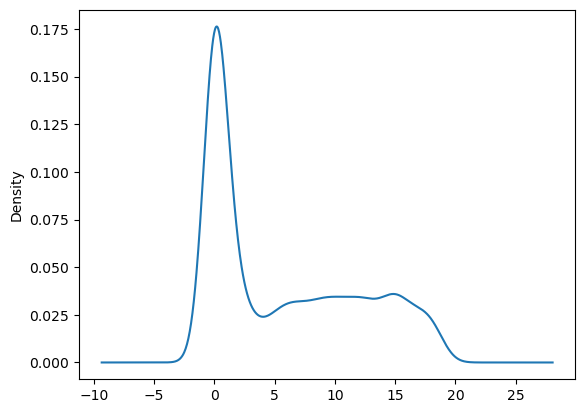

In [20]:
df.atractivo_turistico.plot.kde();

Vemos que hay muchos con poco interes turistico, unos cuantos con algo de interes turistico, y muy pocos con mucho interes turistico.

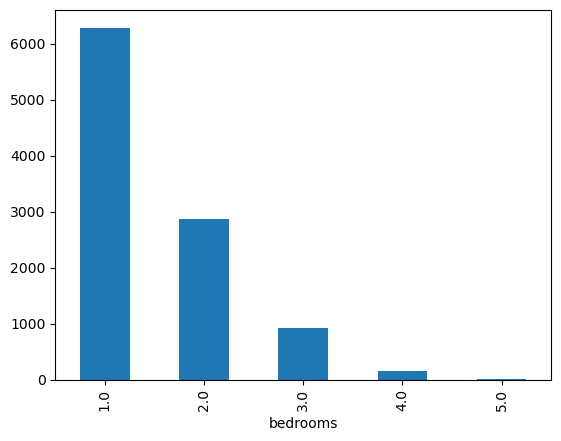

In [23]:
# Veamos un grafico de barras de bedrooms:
df.bedrooms.value_counts().sort_index().plot.bar();

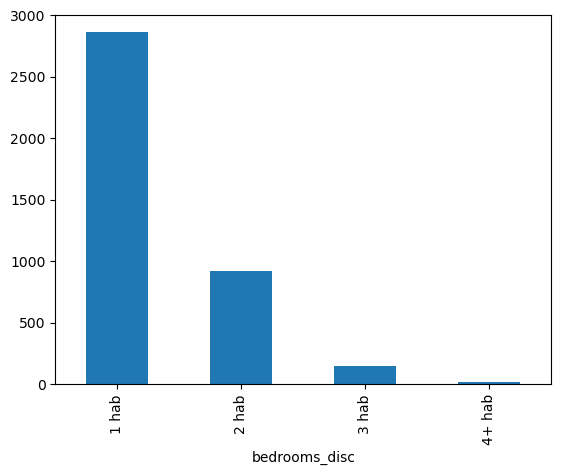

In [26]:
# Discretizo bedrooms en las categorias 1, 2, 3 y 4+
df['bedrooms_disc'] = pd.cut(df['bedrooms'], bins=[1,2,3,4,np.inf], labels=['1 hab', '2 hab', '3 hab', '4+ hab'])
df.bedrooms_disc.value_counts().sort_index().plot.bar();

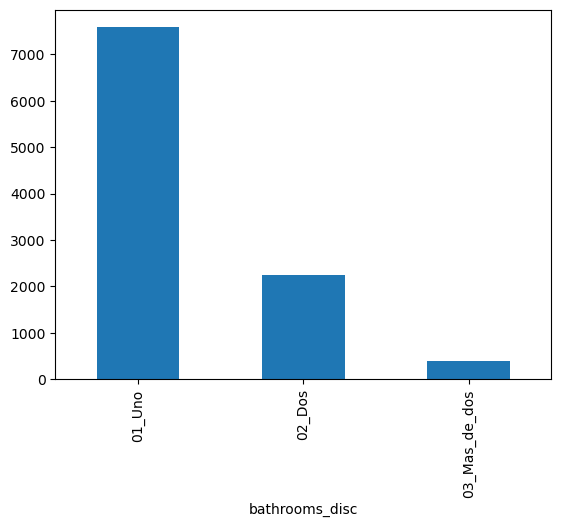

In [28]:
# Discretizo ahora bathrooms en 01_Uno, 02_Dos, 03_Mas_de_dos:
df['bathrooms_disc'] = pd.cut(df['bathrooms'], bins=[0,1,2,np.inf], labels=['01_Uno', '02_Dos', '03_Mas_de_dos'])
df.bathrooms_disc.value_counts().sort_index().plot.bar();

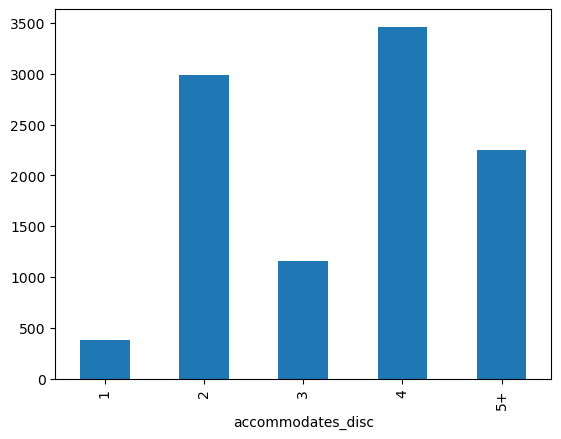

In [31]:
# Ahora discretizamos accommodates en 1, 2, 3, 4 y 5+
df['accommodates_disc'] = pd.cut(df['accommodates'], bins=[0,1,2,3,4,np.inf], labels=['1', '2', '3', '4', '5+'])
df.accommodates_disc.value_counts().sort_index().plot.bar();

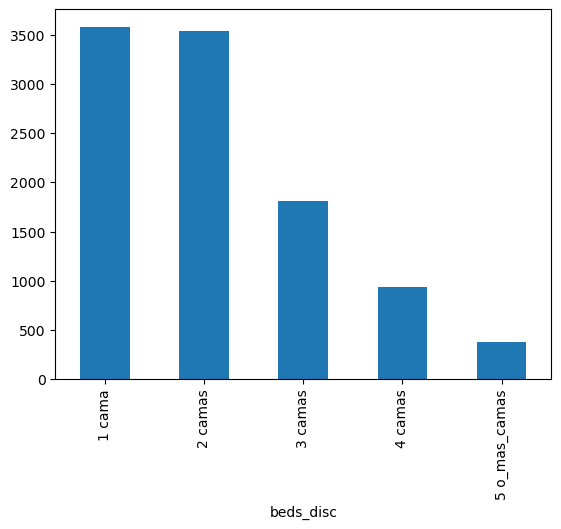

In [34]:
# Por último discretizamos beds en <1,2,3,4,>4
df['beds_disc'] = pd.cut(df['beds'], bins=[0,1,2,3,4,np.inf], labels=['1 cama', '2 camas', '3 camas', '4 camas', '5 o_mas_camas'])
df.beds_disc.value_counts().sort_index().plot.bar();

In [35]:
# Guardamos esta tabla en la base de datos:
con = sqlite3.connect('../datos/intermedios/mercado_inmobiliario.db')
df.to_sql('tablon_analitico', con, if_exists='replace', index=False)
con.close()